In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def phase_shift_with_noise(samples, phase_shift_rad, noise_std):
  """
  Applies a phase shift to a set of complex samples and adds Gaussian noise.

  Args:
    samples: A numpy array of complex samples.
    phase_shift_rad: The amount of phase shift to apply in radians.
    noise_std: The standard deviation of the Gaussian noise.

  Returns:
    A numpy array of complex samples with the applied phase shift and added noise.
  """

  # Create a complex exponential with the phase shift.
  phase_factor = np.exp(1j * phase_shift_rad)

  # Apply the phase shift to each sample.
  shifted_samples = samples * phase_factor

  # Add Gaussian noise to the shifted samples.
  noise = np.random.normal(0, noise_std, len(samples)) + 1j * np.random.normal(0, noise_std, len(samples))
  noisy_samples = shifted_samples + noise

  return noisy_samples
    
# Parameters
frequency = 10  # Frequency of the sine wave in Hz
duration = 1  # Duration of the signal in seconds
sampling_rate = 100  # Sampling rate in Hz

# Generate the time vector
t = np.linspace(0, duration, int(sampling_rate * duration), False)
print(t.shape)

# Generate the complex sine wave
tx = 1*np.exp(2j * np.pi * frequency * t)
rx = 0.2*phase_shift_with_noise(tx, 1, 0.2)
rx[0:50] = 0 + 0j

(100,)


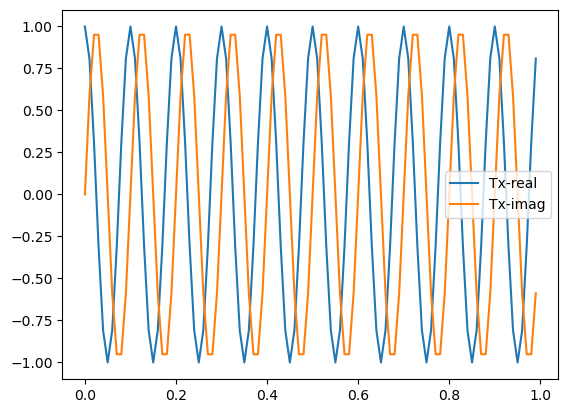

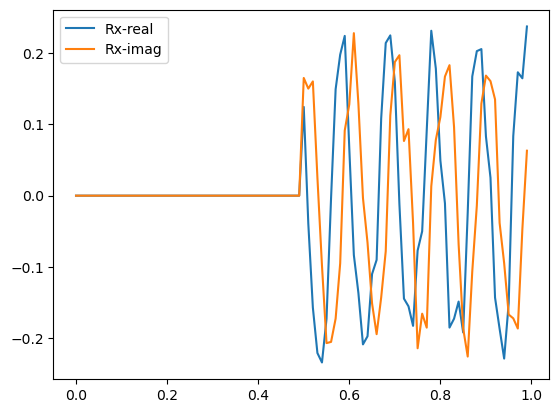

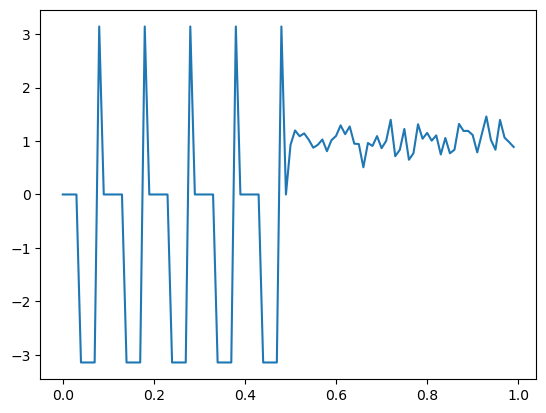

In [30]:
plt.plot(t, np.real(tx), label='Tx-real')
plt.plot(t, np.imag(tx), label='Tx-imag')
plt.legend()
plt.show()

plt.figure()
plt.plot(t, np.real(rx), label='Rx-real')
plt.plot(t, np.imag(rx), label='Rx-imag')
plt.legend()
plt.show()

plt.figure()
plt.plot(t,np.angle(rx/tx))

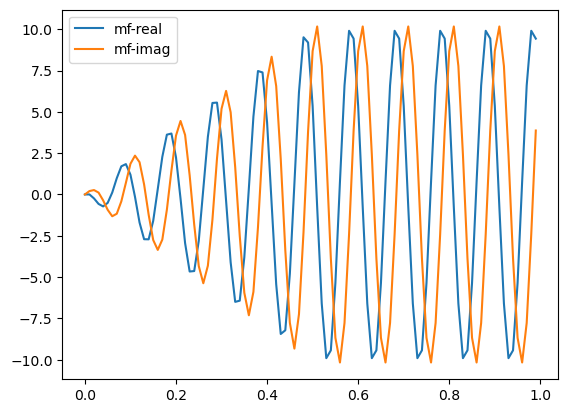

In [33]:
# Create the matched filter
matched_filter = np.conjugate(np.flip(tx))
# Apply the matched filter to the signal
output = signal.convolve(rx, matched_filter, mode='same')
plt.plot(t, np.real(output), label='mf-real')
plt.plot(t, np.imag(output), label='mf-imag')
plt.legend()
plt.show()

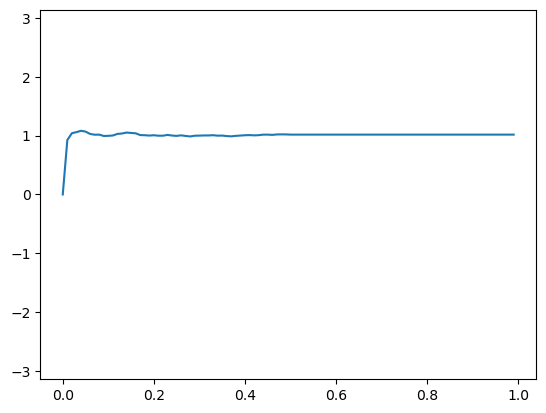

In [34]:
phase = np.angle(output/tx)
plt.ylim([-np.pi,np.pi])
plt.plot(t,phase)

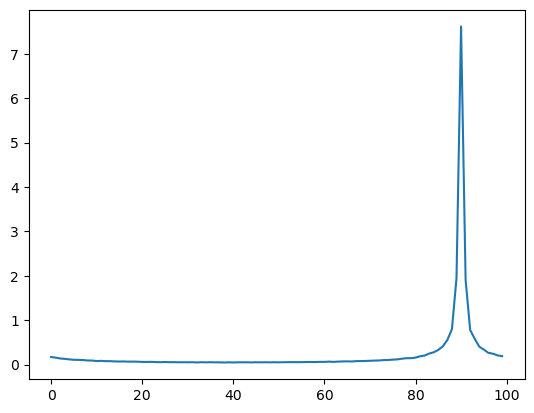

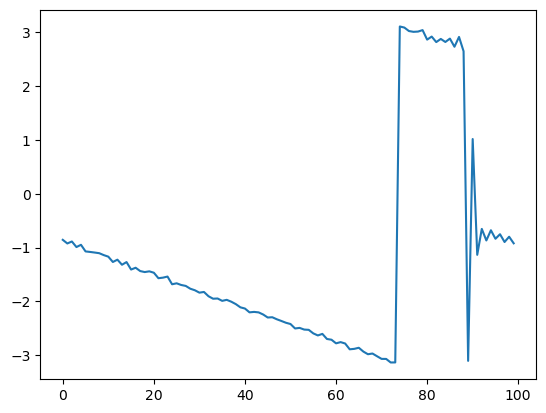

In [36]:
output_f = np.fft.ifft(output)
plt.plot(np.abs(output_f))
plt.figure()
plt.plot(np.angle(output_f))